In [2]:
import pandas as pd
import numpy as np

df_car = pd.read_csv("/workspaces/mlzoomcamp_rama/module1/car_fuel_efficiency_2026.csv")

In [3]:
df_car.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [4]:
df_car = df_car.drop(['num_doors','origin','drivetrain','num_cylinders','acceleration','fuel_type'],axis=1)

In [5]:
df_car.head()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

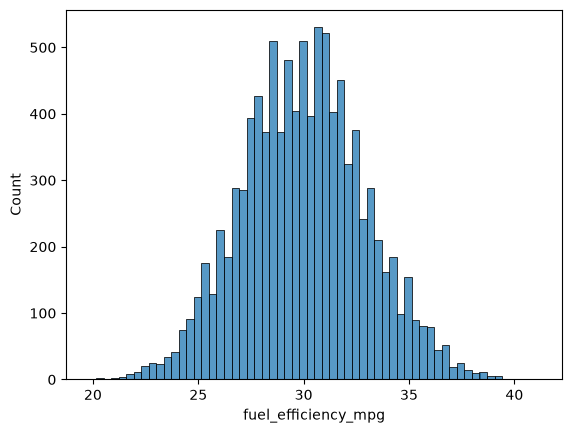

In [6]:
import seaborn as sns

sns.histplot(df_car['fuel_efficiency_mpg'])

<Axes: >

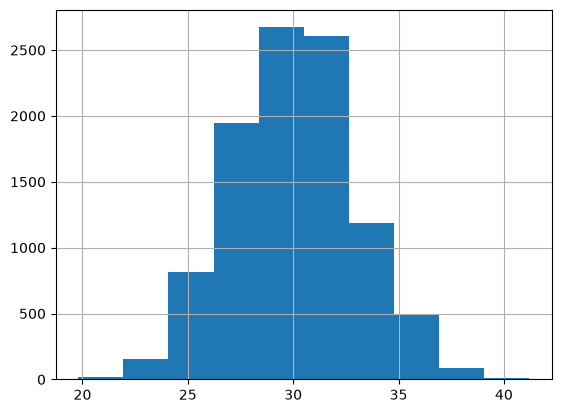

In [7]:
import matplotlib.pyplot as plt

df_car['fuel_efficiency_mpg'].hist()

In [8]:
df_car.isnull().sum()

model_year               0
engine_displacement      0
horsepower             877
vehicle_weight           0
fuel_efficiency_mpg      0
dtype: int64

In [9]:
df_car['horsepower'].median()

np.float64(254.0)

In [10]:
n = len(df_car)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_car.iloc[idx[:n_train]]
df_val = df_car.iloc[idx[n_train:n_train + n_val]]
df_test = df_car.iloc[idx[n_train + n_val:]]

In [11]:
df_train.isnull().sum()

model_year               0
engine_displacement      0
horsepower             538
vehicle_weight           0
fuel_efficiency_mpg      0
dtype: int64

In [12]:
df_car_mean = df_train.copy()

df_car_mean['horsepower'] = df_car_mean['horsepower'].fillna(df_car['horsepower'].mean())

In [13]:
df_car_mean.head()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
6252,2015,1900,239.000000,3790,32.5
4684,1992,2000,224.000000,4380,29.1
1731,2022,2330,286.000000,4090,34.1
4742,1997,2300,254.446016,4150,30.6
4521,2001,2340,269.000000,4400,30.7


In [14]:
df_car_zero = df_train.copy()

df_car_zero['horsepower'] = df_car_zero['horsepower'].fillna(0)

In [15]:
df_car_zero.head()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
6252,2015,1900,239.0,3790,32.5
4684,1992,2000,224.0,4380,29.1
1731,2022,2330,286.0,4090,34.1
4742,1997,2300,0.0,4150,30.6
4521,2001,2340,269.0,4400,30.7


In [16]:
def train_linear_reg(X,Y):

    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])

    XTX = X.T.dot(X)
    XTXINV = np.linalg.inv(XTX)
    final_x = XTXINV.dot(X.T).dot(Y)

    return final_x
    

In [17]:
Y_train = df_car_mean.pop('fuel_efficiency_mpg')

X_train = df_car_mean.to_numpy()

In [18]:
wghts = train_linear_reg(X_train,Y_train)

In [19]:
wghts

array([-1.53298090e+02,  1.01979765e-01, -1.02389462e-03, -6.48573636e-03,
       -3.88827828e-03])

In [20]:
Y_train_zero = df_car_zero.pop('fuel_efficiency_mpg')

X_train_zero = df_car_zero.to_numpy()

In [21]:
wghts_zero = train_linear_reg(X_train_zero,Y_train_zero)

In [22]:
wghts_zero

array([-1.53884962e+02,  1.02146785e-01, -1.51505520e-03, -4.74024796e-06,
       -3.95418397e-03])

In [23]:
def calc_rmse(Y,Ycap):
    se = (Y-Ycap)**2
    mse = se.mean()
    return np.sqrt(mse)

In [24]:
Y_pred = wghts[0] + X_train.dot(wghts[1:])

In [25]:
score_mean = calc_rmse(Y_train,Y_pred)

In [26]:
round(score_mean,3)

np.float64(2.198)

In [27]:
Y_pred_zero = wghts_zero[0] + X_train_zero.dot(wghts_zero[1:])
score_zero = calc_rmse(Y_train_zero,Y_pred_zero)


In [28]:
round(score_zero,3)

np.float64(2.2)

In [29]:
Y_train_val = df_val.pop('fuel_efficiency_mpg')
X_train_val = df_val.to_numpy()

In [30]:
Y_pred_val_zero = wghts_zero[0] + X_train_val.dot(wghts_zero[1:])

In [31]:
Y_pred_val_mean = wghts[0] + X_train_val.dot(wghts[1:])

In [32]:
print(f"validation RMSE score for zero fillining NaN : {round(calc_rmse(Y_train_val,Y_pred_val_zero),3)}")

print(f"validation RMSE score for mean fillining NaN : {round(calc_rmse(Y_train_val,Y_pred_val_mean),3)}")

validation RMSE score for zero fillining NaN : 2.19
validation RMSE score for mean fillining NaN : 2.186


In [33]:
def train_linear_regression_reg(X, Y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(Y)

    return w_full

In [34]:
df_val['horsepower'] = df_val['horsepower'].fillna(0)

X_train_val = df_val.to_numpy()

In [35]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    weights = train_linear_regression_reg(X_train_zero,Y_train_zero,r) # you train on training data set
    Y_pred_zero_reg = weights[0] + X_train_val.dot(weights[1:])        # you validate on validation data set
    score_zero_reg = calc_rmse(Y_train_val,Y_pred_zero_reg)

    print(f"regularization parameter : {r} , RMSE score : {round(score_zero_reg,4)}")
    

regularization parameter : 0 , RMSE score : 2.2053
regularization parameter : 0.01 , RMSE score : 2.2058
regularization parameter : 0.1 , RMSE score : 2.2241
regularization parameter : 1 , RMSE score : 2.3492
regularization parameter : 5 , RMSE score : 2.4094
regularization parameter : 10 , RMSE score : 2.4195
regularization parameter : 100 , RMSE score : 2.4292


In [36]:
def prepare_df(df):
    Y_train_prep = df.pop('fuel_efficiency_mpg')
    df['horsepower'] = df['horsepower'].fillna(0)
    X_train_prep = df.to_numpy()

    return X_train_prep,Y_train_prep

In [39]:
rmse_arr = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_train_seed = df_car.iloc[idx[:n_train]]
    df_val_seed = df_car.iloc[idx[n_train:n_train + n_val]]
    df_test_seed = df_car.iloc[idx[n_train + n_val:]]

    X_train_seed,Y_train_seed = prepare_df(df_train_seed)

    wghts_seed = train_linear_reg(X_train_seed,Y_train_seed)

    X_val_seed,Y_val_seed = prepare_df(df_val_seed)

    Y_pred_val_seed = wghts_seed[0] + X_val_seed.dot(wghts_seed[1:])

    Y_rmse = calc_rmse(Y_val_seed,Y_pred_val_seed)

    rmse_arr.append(Y_rmse)

    print(f"random seed value : {seed} , RMSE score : {round(Y_rmse,3)}")

print(f"Standard deviation of all scores {round(np.std(rmse_arr),3)}")
    

random seed value : 0 , RMSE score : 2.239
random seed value : 1 , RMSE score : 2.202
random seed value : 2 , RMSE score : 2.163
random seed value : 3 , RMSE score : 2.204
random seed value : 4 , RMSE score : 2.202
random seed value : 5 , RMSE score : 2.246
random seed value : 6 , RMSE score : 2.27
random seed value : 7 , RMSE score : 2.191
random seed value : 8 , RMSE score : 2.217
random seed value : 9 , RMSE score : 2.207
Standard deviation of all scores 0.029


In [43]:
idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train_seed = df_car.iloc[idx[:n_train]]
df_val_seed = df_car.iloc[idx[n_train:n_train + n_val]]
df_test_seed = df_car.iloc[idx[n_train + n_val:]]

df_train_seed = pd.concat([df_train_seed,df_val_seed])

X_train_seed,Y_train_seed = prepare_df(df_train_seed)

wghts_seed = train_linear_regression_reg(X_train_seed,Y_train_seed)

X_test_seed,Y_test_seed = prepare_df(df_test_seed)

Y_pred_test_seed = wghts_seed[0] + X_test_seed.dot(wghts_seed[1:])

Y_rmse = calc_rmse(Y_test_seed,Y_pred_test_seed)

print(f"RMSE score : {round(Y_rmse,3)}")
    

RMSE score : 2.236
